In [12]:
import pandas as pd
import re
from functools import reduce
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf 
from tensorflow import keras    
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import zscore
import matplotlib.pyplot as plt  
import seaborn as sns
import os
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random

In [13]:
tf.keras.backend.clear_session()
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [14]:
df_spatial=pd.read_csv("/data/kumarr17/Spatial_transcriptomics_data/GSE238264/processed/smoothed_expression_radius2.csv")
df_gene_exp_tcga_bulk = pd.read_csv("/data/kumarr17/merged_sample_mtx/"+"TCGA"+"_Merged_mRNA_Expression.tsv", index_col='Unnamed: 0')

In [16]:
tcga_features = pd.read_csv("/data/kumarr17/common_features_ver3.txt", header=None)
cyt_features = pd.read_csv("/data/kumarr17/common_cyt_nichenet_gulden_tcga.txt", header=None)
tcga_features_list=list(tcga_features[0])
cyt_features_list=list(cyt_features[0])

In [17]:
# ============================================================
# SETTINGS
# ============================================================

context = "TCGA"

# Already-common input features
feature_list = tcga_features_list

# Cytokines to train/predict
cyt_tmp = cyt_features_list

pred_df_list = []


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = "/data/kumarr17/fixed_feature_cyt_result/ST_result/"

# Create directory if it does not already exist
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    "pred_cyt_on_spatial_spot_fixed_features.csv"
)


# ============================================================
# REPRODUCIBILITY
# ============================================================

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)


# ============================================================
# LOAD TCGA
# ============================================================

df_gene_exp_tcga_bulk = pd.read_csv(
    f"/data/kumarr17/merged_sample_mtx/{context}_Merged_mRNA_Expression.tsv",
    index_col="Unnamed: 0"
)


# ============================================================
# TCGA INPUT MATRIX
# ============================================================

X_tcga_df = df_gene_exp_tcga_bulk[
    feature_list
].copy()

print("Number of input features:", len(feature_list))
print("Number of cytokines:", len(cyt_tmp))
print("Number of TCGA samples:", len(X_tcga_df))


# ============================================================
# ROW-WISE Z-SCORE TCGA
# ============================================================

row_mean_tcga = X_tcga_df.mean(axis=1)

row_std_tcga = (
    X_tcga_df
    .std(axis=1)
    .replace(0, 1)
)

X_tcga_z = (
    X_tcga_df
    .sub(row_mean_tcga, axis=0)
    .div(row_std_tcga, axis=0)
)

X_tcga_z = X_tcga_z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_tcga = X_tcga_z.to_numpy(
    dtype=np.float32
)


# ============================================================
# FIT STANDARD SCALER ON TCGA
# ============================================================

scaler = StandardScaler()

X_tcga_scaled = scaler.fit_transform(
    X_tcga
).astype(np.float32)


# ============================================================
# SPATIAL INPUT MATRIX
# EXACT SAME FEATURES AND ORDER
# ============================================================

X_spatial_df = df_spatial[
    feature_list
].copy()

print("Number of spatial spots:", len(X_spatial_df))


# ============================================================
# ROW-WISE Z-SCORE SPATIAL
# ============================================================

row_mean_spatial = X_spatial_df.mean(axis=1)

row_std_spatial = (
    X_spatial_df
    .std(axis=1)
    .replace(0, 1)
)

X_spatial_z = (
    X_spatial_df
    .sub(row_mean_spatial, axis=0)
    .div(row_std_spatial, axis=0)
)

X_spatial_z = X_spatial_z.replace(
    [np.inf, -np.inf],
    np.nan
).fillna(0)

X_spatial = X_spatial_z.to_numpy(
    dtype=np.float32
)


# ============================================================
# APPLY TCGA-FITTED SCALER TO SPATIAL
# ============================================================

X_spatial_scaled = scaler.transform(
    X_spatial
).astype(np.float32)


# ============================================================
# MODEL BUILDER
# ============================================================

def build_fcnn(input_dim):

    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


# ============================================================
# DEFINE SPOT INDEX ONCE
# ============================================================

if "spot_id" in df_spatial.columns:

    spot_index = df_spatial["spot_id"].tolist()

else:

    spot_index = df_spatial.index


# ============================================================
# TRAIN ON TCGA AND PREDICT SPATIAL
# ============================================================

for yy, cytokine_to_check in enumerate(cyt_tmp):

    print(
        f"Training {yy + 1}/{len(cyt_tmp)}: "
        f"{cytokine_to_check}"
    )


    # --------------------------------------------------------
    # TCGA TARGET
    # --------------------------------------------------------

    y_tcga = df_gene_exp_tcga_bulk[
        [cytokine_to_check]
    ].to_numpy(
        dtype=np.float32
    )


    # --------------------------------------------------------
    # CLEAR PREVIOUS MODEL
    # --------------------------------------------------------

    tf.keras.backend.clear_session()


    # --------------------------------------------------------
    # BUILD NEW CYTOKINE-SPECIFIC MODEL
    # --------------------------------------------------------

    final_model = build_fcnn(
        X_tcga_scaled.shape[1]
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    early_stop = keras.callbacks.EarlyStopping(
        monitor="loss",
        patience=5,
        restore_best_weights=True
    )


    # --------------------------------------------------------
    # TRAIN ON ALL TCGA SAMPLES
    # --------------------------------------------------------

    final_model.fit(
        X_tcga_scaled,
        y_tcga,
        epochs=50,
        batch_size=64,
        verbose=0,
        callbacks=[early_stop]
    )


    # --------------------------------------------------------
    # PREDICT ON ALL SPATIAL SPOTS
    # --------------------------------------------------------

    y_pred_spatial = final_model.predict(
        X_spatial_scaled,
        verbose=0
    ).ravel()


    # --------------------------------------------------------
    # STORE CYTOKINE PREDICTIONS
    # --------------------------------------------------------

    df_pred_score = pd.DataFrame(
        y_pred_spatial,
        index=spot_index,
        columns=[cytokine_to_check]
    )

    pred_df_list.append(
        df_pred_score
    )


# ============================================================
# COMBINE ALL CYTOKINES
# ============================================================

pred_cyt_on_spatial_spot = pd.concat(
    pred_df_list,
    axis=1
)


# ============================================================
# SAVE
# ============================================================

pred_cyt_on_spatial_spot.to_csv(
    output_file
)


# ============================================================
# SUMMARY
# ============================================================

print("\n============================================")
print("FINISHED")
print("============================================")

print(
    "Final prediction matrix shape:",
    pred_cyt_on_spatial_spot.shape
)

print(
    "Number of spots:",
    pred_cyt_on_spatial_spot.shape[0]
)

print(
    "Number of predicted cytokines:",
    pred_cyt_on_spatial_spot.shape[1]
)

print(
    "Saved to:",
    output_file
)

print(
    pred_cyt_on_spatial_spot.head()
)

Number of input features: 6075
Number of cytokines: 645
Number of TCGA samples: 9491
Number of spatial spots: 17292
Training 1/645: INHA
Training 2/645: FGF7
Training 3/645: BMP6
Training 4/645: IL25
Training 5/645: CCL21
Training 6/645: LIPH
Training 7/645: SFTPA1
Training 8/645: FGF23
Training 9/645: ADCYAP1
Training 10/645: MIA
Training 11/645: VCAM1
Training 12/645: BMP15
Training 13/645: ARF1
Training 14/645: ANGPTL4
Training 15/645: PODXL2
Training 16/645: IL18
Training 17/645: FGF21
Training 18/645: COL4A5
Training 19/645: FAT4
Training 20/645: MADCAM1
Training 21/645: RGMA
Training 22/645: PDGFC
Training 23/645: PLAT
Training 24/645: ADAM28
Training 25/645: IL24
Training 26/645: DEFB1
Training 27/645: FN1
Training 28/645: PNOC
Training 29/645: CAMP
Training 30/645: CSHL1
Training 31/645: OLFM2
Training 32/645: A2M
Training 33/645: CEL
Training 34/645: GRP
Training 35/645: MUC7
Training 36/645: MLN
Training 37/645: IL1F10
Training 38/645: CCL20
Training 39/645: PMCH
Training 40/

In [27]:
#### Import the HCC spot prediction probablities
df_pred_cyt_spot=pd.read_csv("/data/kumarr17/fixed_feature_cyt_result/ST_result/pred_cyt_on_spatial_spot_fixed_features.csv",index_col='Unnamed: 0')

In [29]:
df_spatial_v1=df_spatial[['spot_id','sample','response']]
df_spatial_v2=df_spatial_v1.set_index('spot_id')
df_pred_cyt_spot_response_merge=pd.merge(df_pred_cyt_spot,df_spatial_v2,left_index=True,right_index=True)
df=df_pred_cyt_spot_response_merge

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# df must contain:
# - spot_id (matching Seurat cell/barcode names)
# - sample
# - response
# - cytokine feature columns

df = df.copy()
df['spot_id'] = df.index

cytokine_cols = [c for c in df.columns if c not in ['spot_id', 'sample', 'response', 'region']]

X = df[cytokine_cols]
y = df['response'].map({'Responder': 1, 'NonResponder': 0})
groups = df['sample'].values

# choose number of folds
n_groups = df['sample'].nunique()
n_splits = min(7, n_groups)

gkf = GroupKFold(n_splits=n_splits)

spot_pred_list = []
sample_results = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
    test_samples = sorted(df.iloc[test_idx]['sample'].unique())

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, class_weight='balanced')
    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    tmp = df.iloc[test_idx][['spot_id', 'sample', 'response']].copy()
    tmp['true_label'] = y_test.values
    tmp['fold'] = fold
    tmp['prob_responder'] = y_prob
    tmp['prob_nonresponder'] = 1 - y_prob
    spot_pred_list.append(tmp)

    # summarize each held-out sample in this fold
    for s in test_samples:
        s_idx = tmp['sample'] == s
        y_prob_s = tmp.loc[s_idx, 'prob_responder'].values
        y_true_s = tmp.loc[s_idx, 'true_label'].iloc[0]

        sample_results.append({
            'fold': fold,
            'sample': s,
            'true_label': int(y_true_s),
            'pred_score_mean': float(np.mean(y_prob_s)),
            'pred_score_median': float(np.median(y_prob_s)),
            'n_spots': int(s_idx.sum())
        })

spot_pred_df = pd.concat(spot_pred_list, axis=0).reset_index(drop=True)
sample_results_df = pd.DataFrame(sample_results)

# -------------------------
# AUC calculations
# -------------------------

# Spot-level AUC
spot_auc = roc_auc_score(
    spot_pred_df['true_label'],
    spot_pred_df['prob_responder']
)

# Sample-level AUC using mean spot probability per sample
sample_auc_mean = roc_auc_score(
    sample_results_df['true_label'],
    sample_results_df['pred_score_mean']
)

# Optional: Sample-level AUC using median spot probability per sample
sample_auc_median = roc_auc_score(
    sample_results_df['true_label'],
    sample_results_df['pred_score_median']
)

print("Spot-level AUC:", spot_auc)
print("Sample-level AUC (mean):", sample_auc_mean)
print("Sample-level AUC (median):", sample_auc_median)

print(sample_results_df)
print(spot_pred_df.head())

spot_pred_df.to_csv(
    "/data/kumarr17/fixed_feature_cyt_result/ST_result/hcc_spot_groupkfold_probabilities.csv",
    index=False
)

sample_results_df.to_csv(
    "/data/kumarr17/fixed_feature_cyt_result/ST_result/hcc_sample_groupkfold_summary.csv",
    index=False
)

Spot-level AUC: 0.7576996640052399
Sample-level AUC (mean): 0.6666666666666667
Sample-level AUC (median): 0.8333333333333334
   fold  sample  true_label  pred_score_mean  pred_score_median  n_spots
0     0   HCC1R           1         0.977554           0.996974     3006
1     1   HCC4R           1         0.100584           0.002153     3002
2     2   HCC2R           1         0.942006           1.000000     2766
3     3  HCC6NR           0         0.901443           0.924201     2575
4     4  HCC7NR           0         0.018276           0.000680     2453
5     5   HCC3R           1         0.989762           0.999647     2170
6     6  HCC5NR           0         0.981227           0.985915     1320
                    spot_id sample   response  true_label  fold  \
0  HCC1R_AAACAAGTATCTCCCA-1  HCC1R  Responder           1     0   
1  HCC1R_AAACACCAATAACTGC-1  HCC1R  Responder           1     0   
2  HCC1R_AAACAGCTTTCAGAAG-1  HCC1R  Responder           1     0   
3  HCC1R_AAACAGGGTCTATA

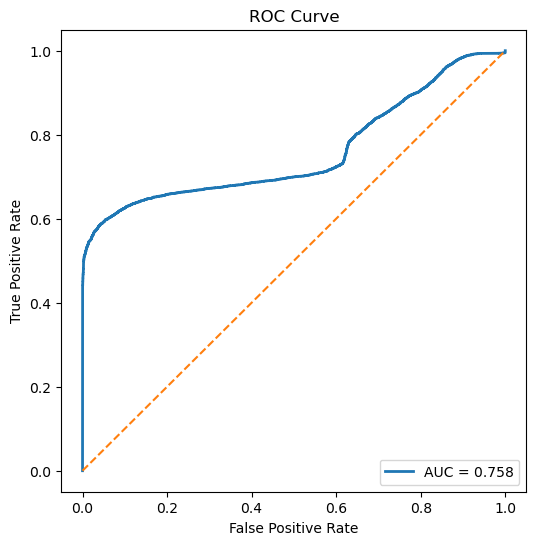

In [38]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ============================================================
# Calculate spot-level AUC
# ============================================================

spot_auc = roc_auc_score(
    spot_pred_df['true_label'],
    spot_pred_df['prob_responder']
)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(
    spot_pred_df['true_label'],
    spot_pred_df['prob_responder']
)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {spot_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()